In [30]:
%pip install gensim>=4.1.2

Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize, Normalizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import simple_preprocess
from gensim.corpora import Dictionary, MmCorpus
import random
import warnings
import os
import services.utils as ut
import services.model as md
np.random.seed(42)
random.seed(42)

In [32]:
warnings.filterwarnings('ignore', category=UserWarning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'

In [33]:
data_df = ut.load_data('customer_support_tickets.csv')
if data_df is not None:
    print("Data loaded successfully")
print(data_df.head())

Data loaded successfully
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   

## Preprocessing

In [34]:
data_df = data_df.drop_duplicates(subset=['Ticket Description'], keep='first')
data_df.reset_index(drop=True, inplace=True)

In [35]:
data_df['text'] = data_df['Ticket Description'].fillna('')

In [36]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # remove URLs
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', ' ', text) # remove email addresses
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII characters
    text = re.sub(r'[^a-z\s]', '', text) 
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)  # remove very short words
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0    having issue with the please assist your billi...
1    having issue with the please assist you need c...
2    facing problem with the not turning was workin...
3    having issue with the please assist you have p...
4    having issue with the please assist note the s...
Name: clean_text, dtype: str

In [37]:
custom_words = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
    'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
    'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
    'use', 'using', 'used','thing', 'something', 'anything', 'everything',
    'way', 'time','issue', 'problem', 'request', 'work', 'working', 'fine',
    'available', 'recent', 'recently','facing', 'doe', 'noticed', 'happening',
    'started', 'happen','different', 'steps', 'did', 'regards','already', 'multiple',
    'last','times','followed', 'reviewed','specific', 'possible', 'related','new',
    'old','find', 'try', 'say', 'mean','name', 'email', 'price', 'one', 'unresolved',
    'add','note', 'may', 'dont', 'know','sure', 'changes', 'performed', 'properly',
    'original','like', 'similar','reported','doesnt', 'sometimes', 'acts', 'works',
    'ensure', 'desired', 'action', 'remains', 'life', 'seems', 'might', 'guide',
    'much', 'others', 'heavily', 'daily', 'task', 'affecting', 'assistance','hoping',
    'persists','didnt','option', 'perform', 'recommendation', 'information', 'official',
    'solution', 'provide', 'making', 'user', 'customer', 'item', 'device','far', 'luck',
    'contact', 'contacted', 'occurring','resolve', 'function', 'came', 'having', 'change',
    'haven', 'let', 'unable', 'able', 'afterward', 'var', 'step', 'order'
}



In [38]:
lemmatizer = WordNetLemmatizer()
final_stopwords = STOPWORDS.union(custom_words)
custom_words_lemma = set([lemmatizer.lemmatize(w.lower()) for w in final_stopwords])

def preprocess(text):
    text = str(text).lower()
    tokens = simple_preprocess(text, deacc=True)
    processed_tokens = []
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        if (lemma not in custom_words_lemma and len(lemma) > 2 and lemma.isalnum()):
            processed_tokens.append(lemma)
    
    return " ".join(processed_tokens)

data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

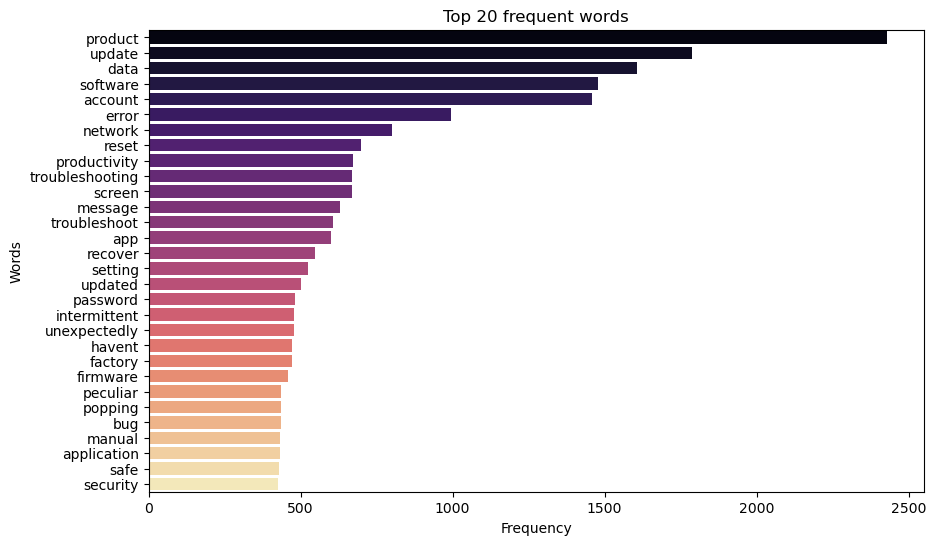

In [39]:
text_data = data_df['processed_text'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)

words, counts = zip(*common_words)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title("Top 20 frequent words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

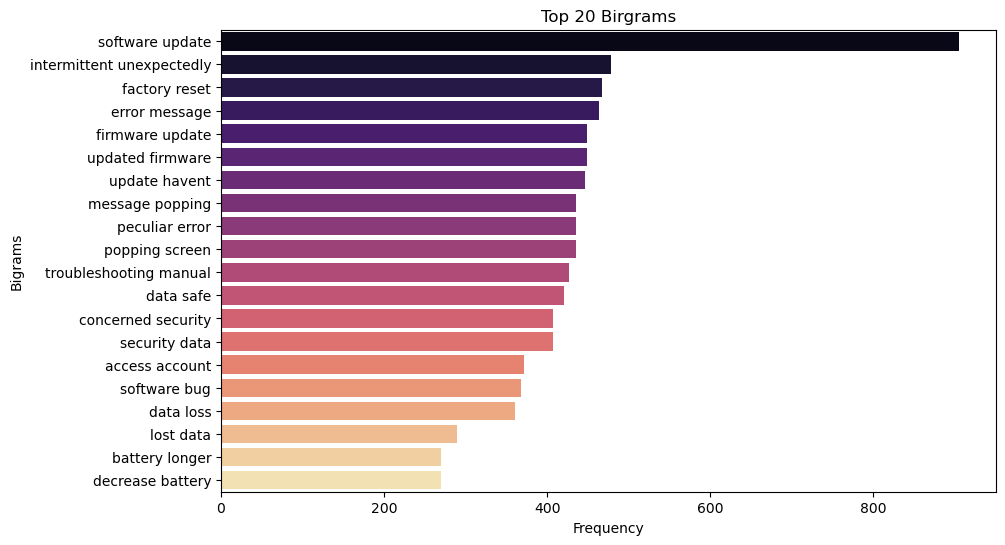

In [40]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma')
plt.title("Top 20 Birgrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

In [41]:
ut.save_data(data_df, 'cleaned_data.csv')

Building the pipeline

In [42]:
def nlp_cleaner(text_list):
    results = []
    for text in text_list:
        cleaned = clean_text(text) 
        processed = preprocess(cleaned)
        results.append(processed)
    return results

### TFIDF

In [43]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7)

X = tfidf.fit_transform(data_df['processed_text'])

In [44]:
tfidf__preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner, validate=False)),
    ('tfidf', TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7))
])

### Embeddings

In [45]:
def clean_for_embeddings(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # remove URLs
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', ' ', text) # remove email addresses
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [46]:
data_df['embedding_text'] = data_df['text'].apply(clean_for_embeddings)

In [47]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [48]:
embeddings = model.encode(data_df['embedding_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/253 [00:00<?, ?it/s]

In [49]:
embeddings = normalize(embeddings)

In [50]:
print(cosine_similarity([embeddings[0]], [embeddings[1]]))
print(cosine_similarity([embeddings[2]], [embeddings[5]]))

[[0.4405267]]
[[0.62984484]]


Building the pipeline

In [51]:
def nlp_cleaner_embeddings(text_list):
    results = []
    for text in text_list:
        cleaned = clean_for_embeddings(text) 
        results.append(cleaned)
    return results

In [52]:
embedding_preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner_embeddings, validate=False)),
    ('embeddings', md.SentenceEmbeddingTransformer(model_name='all-MiniLM-L6-v2')),
    ('normalize', Normalizer())
])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Modelling

### Baseline Model

#### Kmeans with TFIDF

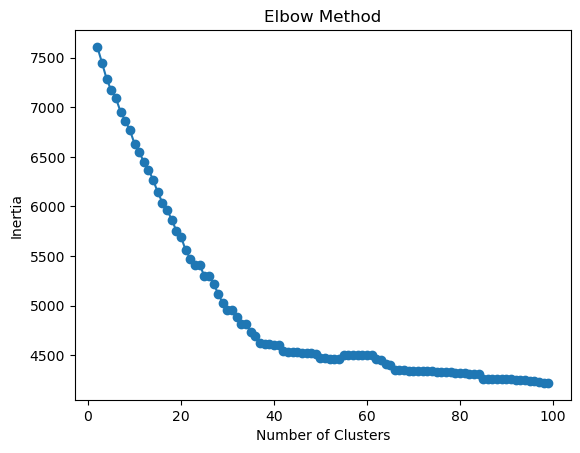

In [53]:
inertia = []

for k in range(2, 100):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(2,100), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [66]:
k = 10

kmeansbaseline = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeansbaseline.fit_predict(X)

array([0, 3, 0, ..., 6, 0, 4], shape=(8077,), dtype=int32)

In [67]:
terms = tfidf.get_feature_names_out()

def get_top_words_per_cluster(model, X, n=20):
    centroids = model.cluster_centers_
    
    for i in range(len(centroids)):
        top_indices = centroids[i].argsort()[-n:]
        top_words = [terms[j] for j in top_indices]
        
        print(f"\nCluster {i}:")
        print(top_words)

get_top_words_per_cluster(kmeansbaseline, X)


Cluster 0:
['model widespread', 'experiencing model', 'widespread', 'experiencing', 'model', 'charger', 'charger charging', 'setting configuration', 'app', 'troubleshooting website', 'configuration', 'purchase', 'charging', 'website', 'setting', 'manual', 'troubleshooting manual', 'troubleshooting', 'productivity', 'product']

Cluster 1:
['app', 'fix', 'update running', 'running latest', 'running', 'latest', 'latest version', 'version', 'product', 'software bug', 'bug', 'firmware update', 'updated firmware', 'firmware', 'updated', 'havent', 'update havent', 'software update', 'software', 'update']

Cluster 2:
['loss file', 'disappeared retrieve', 'document disappeared', 'file document', 'document', 'encountered data', 'encountered', 'retrieve', 'recover', 'lost data', 'lost', 'file', 'deleted', 'security', 'concerned', 'security data', 'concerned security', 'data safe', 'safe', 'data']

Cluster 3:
['locked unlock', 'logging account', 'reset', 'logging', 'account locked', 'account acco

In [68]:
labels = kmeansbaseline.labels_
distribution = pd.Series(labels).value_counts().sort_index()
print("Cluster Distribution:")
print(distribution)

Cluster Distribution:
0    3338
1    1330
2     771
3     680
4     311
5     237
6     323
7     523
8     381
9     183
Name: count, dtype: int64


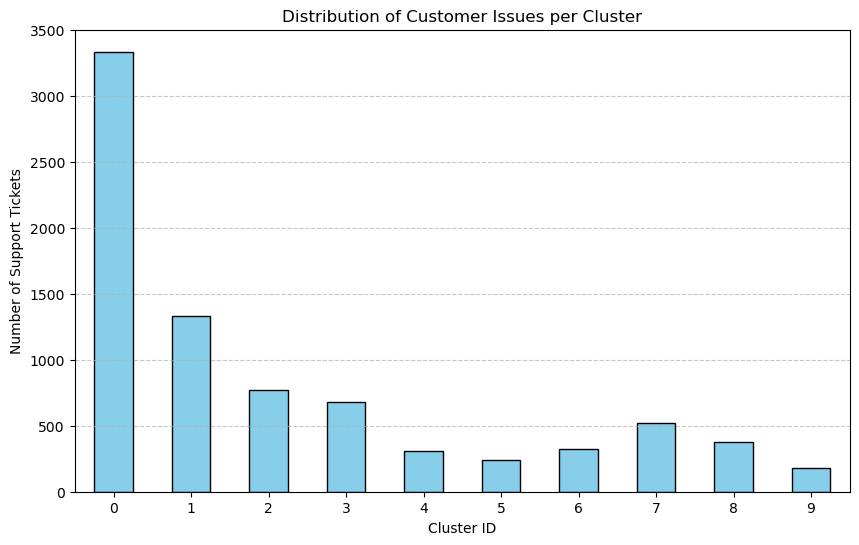

In [69]:
plt.figure(figsize=(10, 6))
distribution.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribution of Customer Issues per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Support Tickets')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()